In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
os.chdir(r"C:\Users\natha_iwo7kj6\Downloads")

df = pd.read_csv("fifa_eda.csv")

print("Archivo cargado correctamente.")

Archivo cargado correctamente.


In [4]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [5]:
#Matriz de correlación
columnas_numericas = [
    "Age",
    "Overall",
    "Potential",
    "Value",
    "Wage",
    "International Reputation",
    "Skill Moves"
]

matriz_correlacion = df[columnas_numericas].corr()

matriz_correlacion

,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves
Age,1.000000,0.452350,-0.253312,0.078315,0.141145,0.253765,0.027649
Overall,0.452350,1.000000,0.660939,0.631848,0.571926,0.499491,0.414463
Potential,-0.253312,0.660939,1.000000,0.579608,0.486413,0.372993,0.354290
Value,0.078315,0.631848,0.579608,1.000000,0.858086,0.656158,0.317246
Wage,0.141145,0.571926,0.486413,0.858086,1.000000,0.668635,0.263205
International Reputation,0.253765,0.499491,0.372993,0.656158,0.668635,1.000000,0.208153
Skill Moves,0.027649,0.414463,0.354290,0.317246,0.263205,0.208153,1.000000


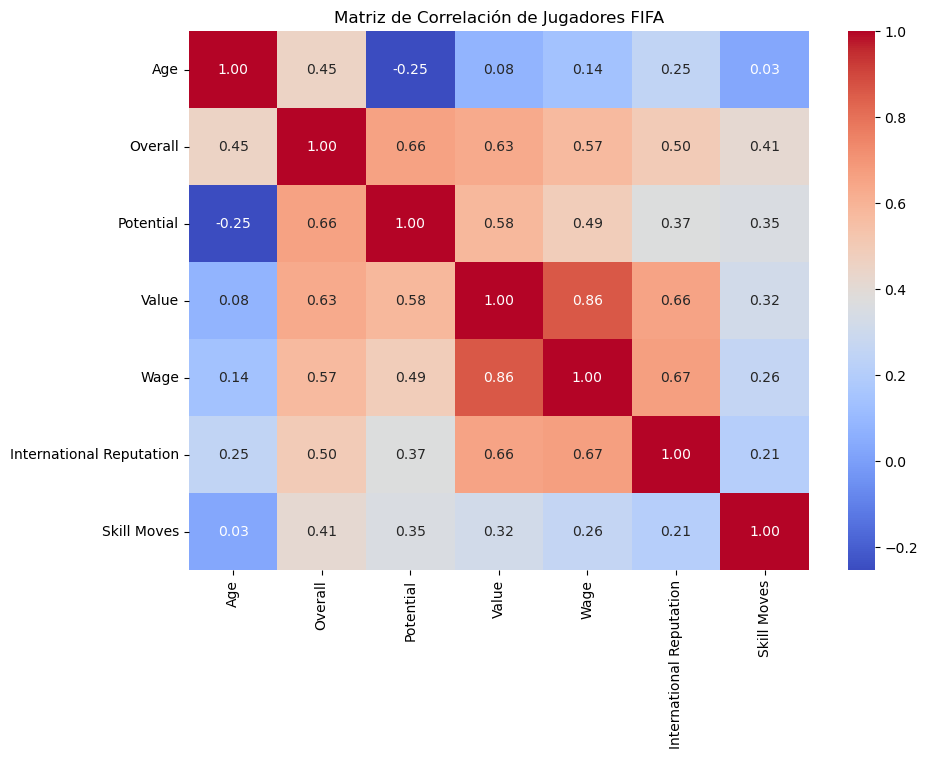

In [6]:
#heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación de Jugadores FIFA")

plt.show()

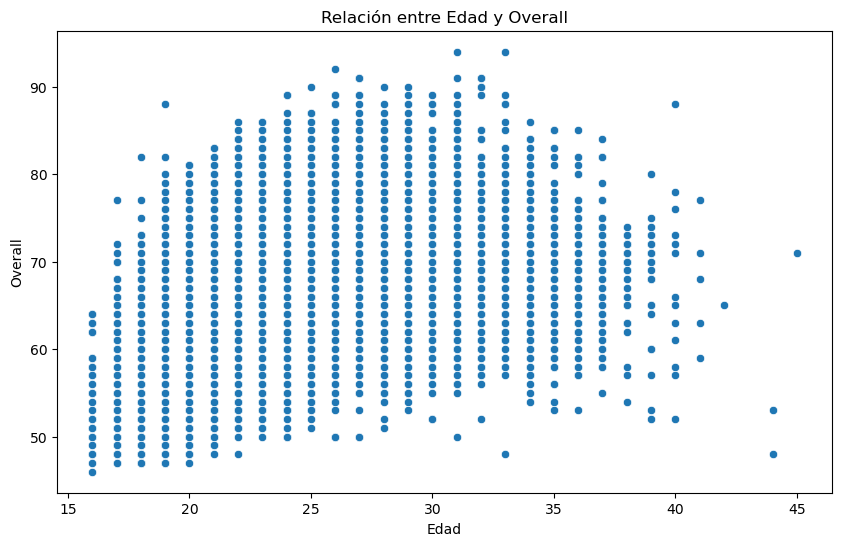

In [7]:
#edad vs overall
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Overall"
)

plt.title("Relación entre Edad y Overall")
plt.xlabel("Edad")
plt.ylabel("Overall")

plt.show()

#El gráfico muestra la relación entre la edad de los jugadores y su valoración Overall. Se puede observar la distribución de las valoraciones según la edad. Los puntos representan jugadores individuales. La concentración de los datos permite analizar si existe una tendencia entre ambas variables, aunque la edad por sí sola no determina el Overall de un jugador.

In [8]:
#numero de jugadores por club
jugadores_por_club = df["Club"].value_counts()

In [10]:
top_clubes = jugadores_por_club.head(20)

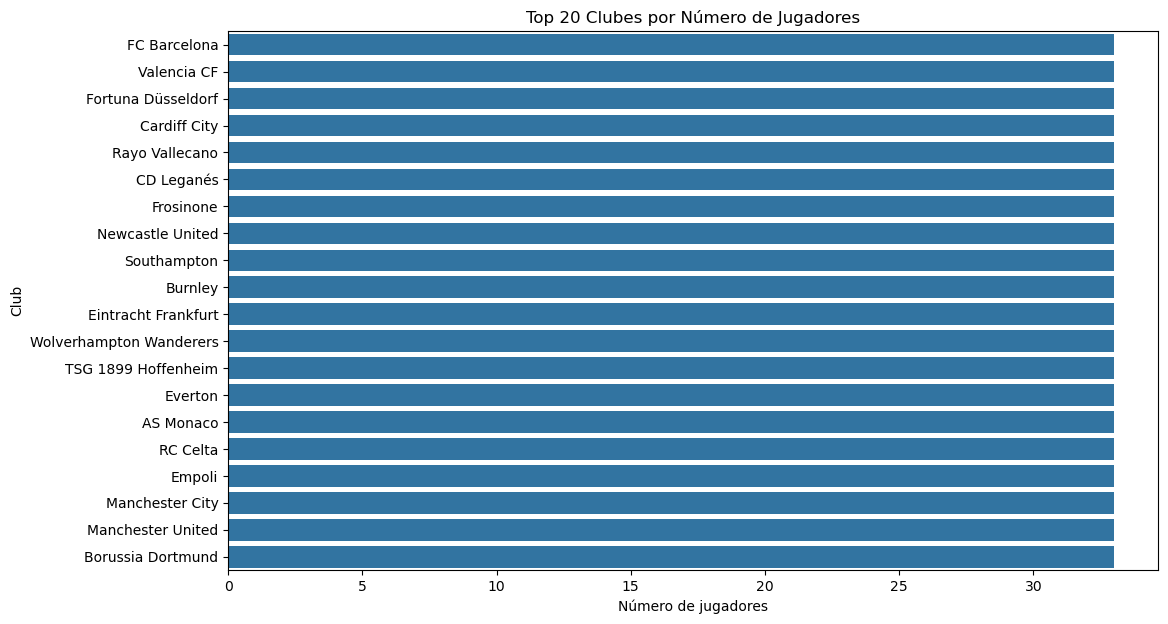

In [11]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_clubes.values,
    y=top_clubes.index
)

plt.title("Top 20 Clubes por Número de Jugadores")
plt.xlabel("Número de jugadores")
plt.ylabel("Club")

plt.show()

In [12]:
#relación de altura vs skill moves
df["Height"].head()

0    5.583333
1    6.166667
2    5.750000
3    6.333333
4    5.916667
Name: Height, dtype: float64

In [17]:
def convertir_altura(altura):
    if pd.isna(altura):
        return None
    
    altura = str(altura)
    
    partes = altura.split(".")
    
    pies = int(partes[0])
    pulgadas = int(partes[1])
    
    return (pies * 30.48) + (pulgadas * 2.54)

In [21]:
df = df.drop(columns=["Height_cm"])

In [22]:
df["Height_cm"] = df["Height"] * 30.48

In [23]:
df[["Height", "Height_cm"]].head(20)

,Height,Height_cm
0,5.583333,170.18
1,6.166667,187.96
2,5.750000,175.26
3,6.333333,193.04
4,5.916667,180.34
5,5.666667,172.72
6,5.666667,172.72
7,6.000000,182.88
8,6.000000,182.88
9,6.166667,187.96


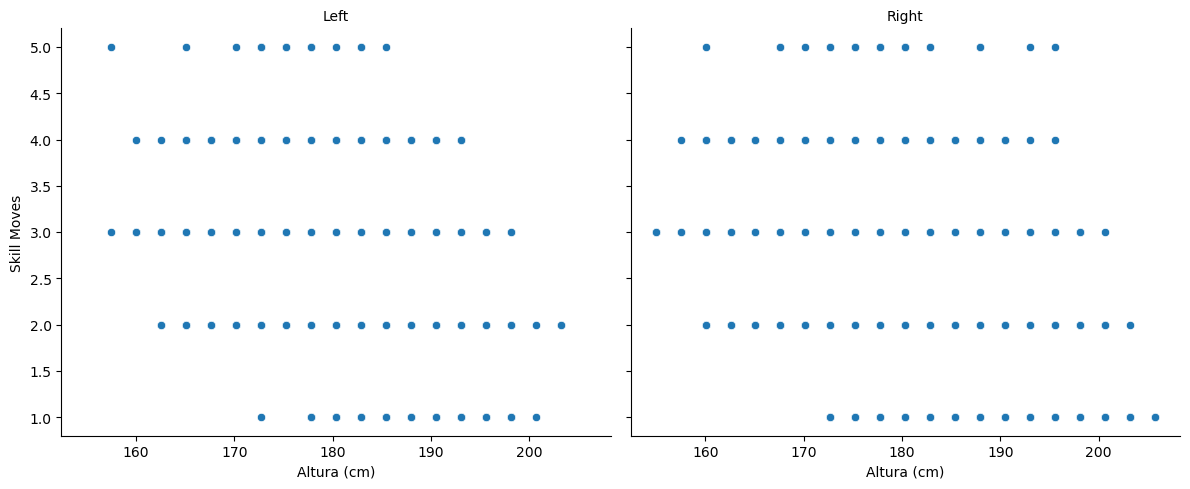

In [24]:
g = sns.FacetGrid(
    df,
    col="Preferred Foot",
    height=5,
    aspect=1.2
)

g.map_dataframe(
    sns.scatterplot,
    x="Height_cm",
    y="Skill Moves"
)

g.set_axis_labels(
    "Altura (cm)",
    "Skill Moves"
)

g.set_titles("{col_name}")

plt.show()

El gráfico multipanel muestra la relación entre la altura de los jugadores y sus Skill Moves, separando los datos según el pie preferido. Esto permite comparar visualmente a los jugadores zurdos y diestros y observar cómo se distribuyen sus habilidades de movimiento según su altura.


Actualización realizada para la tarea de Github


Actualización realizada desde sourcetree